In [1]:
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# import plotly.express as px

In [2]:
load_dotenv()
database_url = os.getenv('DATABASE_URL')

engine = create_engine(database_url)

df = pd.read_sql('SELECT * FROM storm_events_details_cleaned', engine)
df2 = pd.read_sql('SELECT * FROM storm_events_details', engine)

In [3]:
df2['EVENT_TYPE'].unique()

array(['Thunderstorm Wind', 'Tornado', 'Winter Storm', 'Winter Weather',
       'Hail', 'Flash Flood', 'Flood', 'Marine Thunderstorm Wind',
       'Excessive Heat', 'High Wind', 'Lightning', 'Marine Hail',
       'Frost/Freeze', 'Sneakerwave', 'Heavy Snow', 'Debris Flow',
       'Cold/Wind Chill', 'Funnel Cloud', 'Marine High Wind',
       'Strong Wind', 'Wildfire', 'Dust Storm', 'Drought', 'Heavy Rain',
       'High Surf', 'Blizzard', 'Extreme Cold/Wind Chill', 'Dense Fog',
       'Lake-Effect Snow', 'Ice Storm', 'Avalanche', 'Heat',
       'Rip Current', 'Waterspout', 'Sleet', 'Astronomical Low Tide',
       'Coastal Flood', 'Marine Strong Wind', 'Freezing Fog',
       'Marine Dense Fog', 'Marine Tropical Storm'], dtype=object)

In [4]:
df['EVENT_TYPE'].unique()

array(['Thunderstorm Wind', 'Tornado', 'Flash Flood', 'Flood', 'Hail',
       'Lightning', 'Marine Thunderstorm Wind', 'Marine Hail',
       'Debris Flow', 'Funnel Cloud', 'Marine High Wind', 'Heavy Rain',
       'Waterspout', 'Marine Strong Wind'], dtype=object)

In [5]:
df.columns

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'DATA_SOURCE'],
      dtype='object')

Creating a function where it changes the K's, M's and B's in damages to being actually float values

In [6]:
df2['DAMAGE_PROPERTY']= df2['DAMAGE_PROPERTY'].fillna('0')
df2['DAMAGE_CROPS'] = df2['DAMAGE_CROPS'].fillna('0')

In [7]:
def written_to_full_amount(row):
    if row[-1:] == 'K':
        return float(row[:-1]) * 1000
    elif row[-1:] == 'M':
        return float(row[:-1]) * 1000000
    elif row[-1:] == 'B':
        return float(row[:-1]) * 1000000000
    else:
        return float(row)

In [8]:
df['DAMAGE_CROPS'].iloc[1][-1:]

'K'

In [ ]:
# Cleaned Dataset
df['DAMAGE_PROPERTY_FLOAT'] = df['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df['DAMAGE_CROPS_FLOAT'] = df['DAMAGE_CROPS'].apply(written_to_full_amount)
df['Total_Damage_Cost'] = df['DAMAGE_CROPS_FLOAT'] + df['DAMAGE_PROPERTY_FLOAT']
df['END_DATE_TIME_DT'] = df['END_DATE_TIME'].apply(pd.to_datetime)

In [ ]:
# Full dataset
df2['DAMAGE_PROPERTY_FLOAT'] = df2['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df2['DAMAGE_CROPS_FLOAT'] = df2['DAMAGE_CROPS'].apply(written_to_full_amount)
df2['Total_Damage_Cost'] = df2['DAMAGE_CROPS_FLOAT'] + df2['DAMAGE_PROPERTY_FLOAT']
df2['END_DATE_TIME_DT'] = df2['END_DATE_TIME'].apply(pd.to_datetime)

In [11]:
df['END_DATE_TIME_DT']

0       2025-03-31 11:06:00
1       2025-03-30 15:55:00
2       2025-06-19 15:29:00
3       2025-04-05 17:35:00
4       2025-04-05 04:25:00
                ...        
28462   2025-06-11 14:51:00
28463   2025-06-03 18:05:00
28464   2025-06-03 18:10:00
28465   2025-06-03 18:22:00
28466   2025-06-03 19:15:00
Name: END_DATE_TIME_DT, Length: 28467, dtype: datetime64[ns]

In [12]:
df.sort_values(by='Total_Damage_Cost',ascending=False)
df_outlier = df[df['Total_Damage_Cost'] <= 1000000000]

In [13]:
df.sort_values(by='Total_Damage_Cost',ascending=False)

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,DATA_SOURCE,DAMAGE_PROPERTY_FLOAT,DAMAGE_CROPS_FLOAT,Total_Damage_Cost,END_DATE_TIME_DT
12669,202505,16,1342,202505,16,1349,202193,1262207,MISSOURI,29,...,38.6446,-90.3039,38.6894,-90.1974,"During the afternoon of May 16th, numerous sup...",CSV,1.600000e+09,0.0,1.600000e+09,2025-05-16 13:49:00
26127,202505,16,1715,202505,16,1732,202009,1274298,ILLINOIS,17,...,37.6553,-89.0945,37.6599,-88.7970,A 500mb shortwave trough moved across the Uppe...,CSV,2.500000e+07,0.0,2.500000e+07,2025-05-16 17:32:00
22282,202506,12,315,202506,12,851,204035,1272324,TEXAS,48,...,29.5100,-98.4100,29.5147,-98.4117,A mid-level shortwave trough moved over Texas ...,CSV,2.300000e+07,0.0,2.300000e+07,2025-06-12 08:51:00
26676,202505,16,1816,202505,16,1829,202011,1274626,KENTUCKY,21,...,37.6597,-88.0484,37.6548,-87.8679,A 500mb shortwave trough moved across the Uppe...,CSV,1.500000e+07,100000.0,1.510000e+07,2025-05-16 18:29:00
8676,202503,14,2227,202503,14,2247,200310,1241249,MISSOURI,29,...,36.7229,-90.5729,36.8607,-90.2986,A major outbreak of severe storms including to...,CSV,1.500000e+07,0.0,1.500000e+07,2025-03-14 22:47:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,202506,30,1741,202506,30,1811,202499,1259481,MARYLAND,24,...,39.4900,-76.3900,39.5039,-76.3737,A boundary stalled across northeast Maryland a...,CSV,0.000000e+00,0.0,0.000000e+00,2025-06-30 18:11:00
15,202504,29,1506,202504,29,1506,201620,1257729,NEW YORK,36,...,42.9100,-77.7500,42.9100,-77.7500,"On Tuesday April 29, a cold front crossed the ...",CSV,0.000000e+00,0.0,0.000000e+00,2025-04-29 15:06:00
16,202505,19,1458,202505,19,1459,204187,1272368,KANSAS,20,...,39.0000,-94.6900,39.0000,-94.6900,Storms brought severe weather to eastern Kansas.,CSV,0.000000e+00,0.0,0.000000e+00,2025-05-19 14:59:00
17,202506,30,2015,202506,30,2030,202499,1259485,MARYLAND,24,...,39.5119,-76.3756,39.5130,-76.3734,A boundary stalled across northeast Maryland a...,CSV,0.000000e+00,0.0,0.000000e+00,2025-06-30 20:30:00


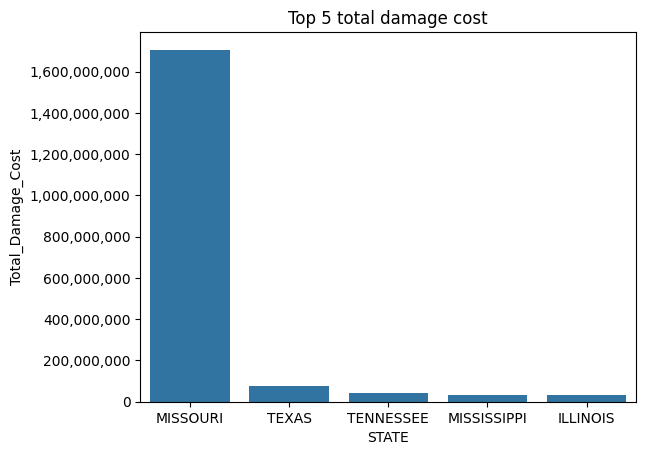

In [14]:
Grouped_State_df = df.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df

ax = sns.barplot(Grouped_State_df.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

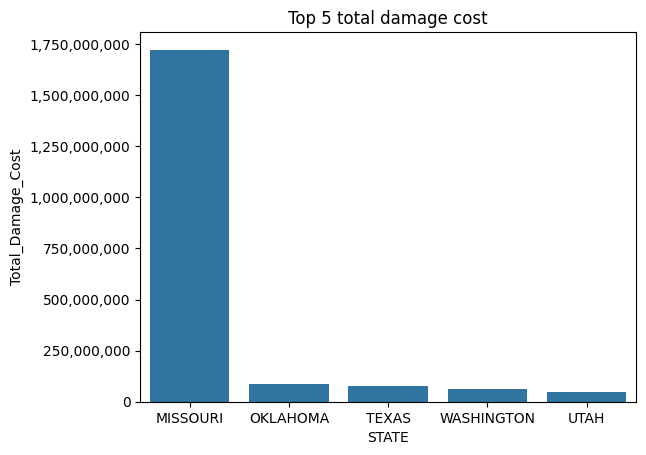

In [26]:
Grouped_State_df2 = df2.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df2

ax = sns.barplot(Grouped_State_df2.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

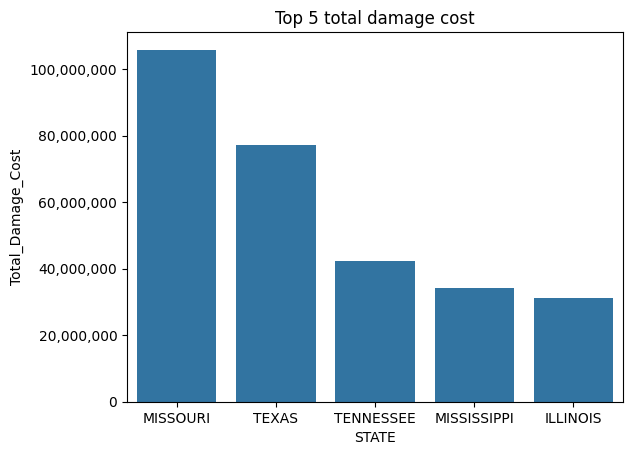

In [15]:
Grouped_State_df_out = df_outlier.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df_out

ax = sns.barplot(Grouped_State_df_out.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

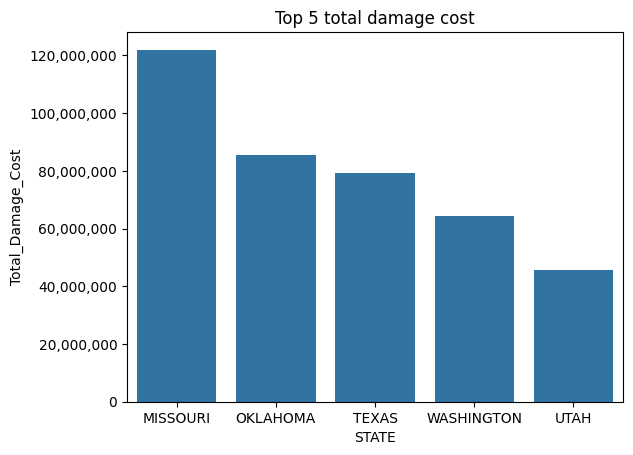

In [27]:
df_outlier2 = df2[df2['Total_Damage_Cost'] <= 1000000000]
Grouped_State_df_out2 = df_outlier2.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df_out2

ax = sns.barplot(Grouped_State_df_out2.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

In [16]:
US_STATE_ABBREV = {
    'ALABAMA': 'AL',
    'ALASKA': 'AK',
    'ARIZONA': 'AZ',
    'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA',
    'COLORADO': 'CO',
    'CONNECTICUT': 'CT',
    'DELAWARE': 'DE',
    'FLORIDA': 'FL',
    'GEORGIA': 'GA',
    'HAWAII': 'HI',
    'IDAHO': 'ID',
    'ILLINOIS': 'IL',
    'INDIANA': 'IN',
    'IOWA': 'IA',
    'KANSAS': 'KS',
    'KENTUCKY': 'KY',
    'LOUISIANA': 'LA',
    'MAINE': 'ME',
    'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA',
    'MICHIGAN': 'MI',
    'MINNESOTA': 'MN',
    'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO',
    'MONTANA': 'MT',
    'NEBRASKA': 'NE',
    'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH',
    'NEW JERSEY': 'NJ',
    'NEW MEXICO': 'NM',
    'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC',
    'NORTH DAKOTA': 'ND',
    'OHIO': 'OH',
    'OKLAHOMA': 'OK',
    'OREGON': 'OR',
    'PENNSYLVANIA': 'PA',
    'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD',
    'TENNESSEE': 'TN',
    'TEXAS': 'TX',
    'UTAH': 'UT',
    'VERMONT': 'VT',
    'VIRGINIA': 'VA',
    'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI',
    'WYOMING': 'WY'
}

In [17]:
Grouped_State_df['STATE']

0            ALABAMA
1             ALASKA
2     AMERICAN SAMOA
3            ARIZONA
4           ARKANSAS
           ...      
61          VIRGINIA
62        WASHINGTON
63     WEST VIRGINIA
64         WISCONSIN
65           WYOMING
Name: STATE, Length: 66, dtype: object

In [18]:
Grouped_State_df['Total_Damage_Cost'].dtype
Grouped_State_df['STATE'] = Grouped_State_df['STATE'].map(US_STATE_ABBREV)
Grouped_State_df['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [19]:
Grouped_State_df_out['Total_Damage_Cost'].dtype
Grouped_State_df_out['STATE'] = Grouped_State_df_out['STATE'].map(US_STATE_ABBREV)
Grouped_State_df_out['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [29]:
Grouped_State_df2['Total_Damage_Cost'].dtype
Grouped_State_df2['STATE'] = Grouped_State_df2['STATE'].map(US_STATE_ABBREV)
Grouped_State_df2['STATE']

Grouped_State_df_out2['Total_Damage_Cost'].dtype
Grouped_State_df_out2['STATE'] = Grouped_State_df_out2['STATE'].map(US_STATE_ABBREV)
Grouped_State_df_out2['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
62     VA
63     WA
64     WV
65     WI
66     WY
Name: STATE, Length: 67, dtype: object

In [30]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df2,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [31]:
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df_out2,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [20]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [21]:
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df_out,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [22]:
# begin_yearmonth = 202501
# for x in range(begin_yearmonth, begin_yearmonth+7):


In [23]:
# df['END_DATE_TIME_DT'] = df['END_DATE_TIME_DT'].dt.to_period("M").dt.to_timestamp()
# df['END_DATE_TIME_DT'].nunique()

In [24]:
# nbformat
# plotly
# kaleido
# import plotly.io as pio

# fig = px.choropleth(
#     data_frame= df,
#     locations = 'STATE',
#     locationmode= 'USA-states',
#     color = 'Total_Damage_Cost',
#     scope = 'usa',
#     animation_frame= 'END_DATE_TIME_DT',
#     color_continuous_scale= 'Viridis'
# )


# fig.show()